<a href="https://colab.research.google.com/github/Tanya-yadav-142/DeepLearningCase_study-197-/blob/main/CIFAR_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

cifar dataset comprises of 10 classes of images with integer labels and 60000 images of  32 × 32 pixels
3 color channels (RGB)

build CNN model to classify images into 10 classes  

sequential=Input → Conv → Pool → Conv → Pool → Dense → Output


A filter (also called kernel) is a small matrix used to detect patterns in images.

1)conv layer : 32 filters

Input image
     ↓
32 filters applied(32 features generated)
     ↓
32 feature maps generated


3x3 kernel:how much will look at once
##element-wise multiplication + sum This operation is called convolution.
ReLU activation
32 x 32 x 3
and it detects edges ,curves,textures,patterns


2.)pooling
reduce img size
reduce computation
retain important features

3.)cv2=model learns more complex features.

4?cv3 more higher car wheels
animal faces
airplane wings


6.)dense=Learns relationships between features.and connected neural netwek

convo=extract features
Relu activation=CNN becomes simple linear transformation
pooling=reduce size
flatten=2d to 1d
dense=learn relationships between extracted features
output=predict class prob

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 47ms/step - accuracy: 0.4369 - loss: 1.5483
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 72s 46ms/step - accuracy: 0.5839 - loss: 1.1759
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 46ms/step - accuracy: 0.6427 - loss: 1.0201
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 85s 48ms/step - accuracy: 0.6778 - loss: 0.9185
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 47ms/step - accuracy: 0.7047 - loss: 0.8437
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 47ms/step - accuracy: 0.7265 - loss: 0.7812
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 72s 46ms/step - accuracy: 0.7460 - loss: 0.7254
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 46ms/step - accuracy: 0.7606 - loss: 0.6777
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 74s 47ms/step - accuracy: 0.7732 - loss: 0.6428
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 47ms/step - accuracy: 0.7892 - loss: 0.6044
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.6998 - loss: 0.9103
313/313 ━━━━━━━━━━━━━━━

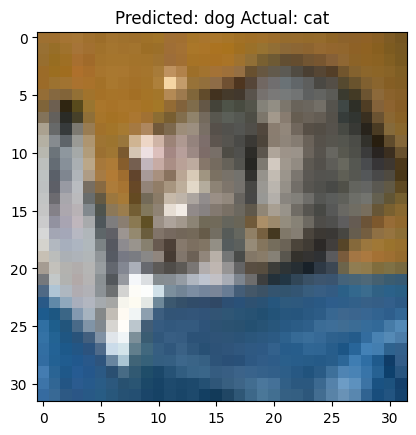

In [ ]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

# Load CIFAR-10 dataset
cifar = keras.datasets.cifar10
(X_train, y_train), (X_test, y_test) = cifar.load_data()

# Normalize pixel values
X_train = X_train / 255.0
X_test = X_test / 255.0

# Class names
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# Build CNN model
model = keras.Sequential([

    keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Conv2D(64,(3,3),activation='relu'),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Conv2D(128,(3,3),activation='relu'),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Flatten(),

    keras.layers.Dense(64,activation='relu'),

    keras.layers.Dense(10,activation='softmax')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
model.fit(X_train,y_train,epochs=10)

# Evaluate model
model.evaluate(X_test,y_test)

# Predict
predictions = model.predict(X_test)

# Show image
plt.imshow(X_test[0])
plt.title("Predicted: " + class_names[np.argmax(predictions[0])] +
          " Actual: " + class_names[y_test[0][0]])
plt.show()